# Week - 3 : Project 
# 🏠 House Prices — Complete Exploratory Data Analysis

## Introduction

This project performs a complete Exploratory Data Analysis (EDA) on the Kaggle House Prices dataset.

The main objective is to understand the factors that influence house sale prices, identify data quality problems, handle missing values, analyze numerical and categorical variables, detect outliers, and discover meaningful relationships between housing features and the target variable `SalePrice`.

## Objectives

- Understand the structure of the dataset
- Analyze numerical and categorical features
- Identify missing values
- Handle missing data appropriately
- Detect duplicate records
- Analyze distributions
- Study relationships between features
- Identify outliers
- Analyze correlations with `SalePrice`
- Create meaningful visualizations
- Generate business/data insights
- Create a cleaned dataset for future machine learning

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

train = pd.read_csv(
    "house-prices-advanced-regression-techniques/train.csv"
)

test = pd.read_csv(
    "house-prices-advanced-regression-techniques/test.csv"
)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


Train Shape: (1460, 81)
Test Shape: (1459, 80)


In [3]:
# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

print("========== DATASET SHAPE ==========")

print("Training data:", train.shape)
print("Testing data :", test.shape)


print("\n========== FIRST 5 ROWS ==========")

display(train.head())


print("\n========== LAST 5 ROWS ==========")

display(train.tail())

========== DATASET SHAPE ==========
Training data: (1460, 81)
Testing data : (1459, 80)

========== FIRST 5 ROWS ==========


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



========== LAST 5 ROWS ==========


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [4]:
# ============================================================
# 5. COLUMN INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("COLUMN INFORMATION")
print("=" * 60)

print("\nTraining columns:")

for i, column in enumerate(train.columns, start=1):
    print(i, ":", column)


COLUMN INFORMATION

Training columns:
1 : Id
2 : MSSubClass
3 : MSZoning
4 : LotFrontage
5 : LotArea
6 : Street
7 : Alley
8 : LotShape
9 : LandContour
10 : Utilities
11 : LotConfig
12 : LandSlope
13 : Neighborhood
14 : Condition1
15 : Condition2
16 : BldgType
17 : HouseStyle
18 : OverallQual
19 : OverallCond
20 : YearBuilt
21 : YearRemodAdd
22 : RoofStyle
23 : RoofMatl
24 : Exterior1st
25 : Exterior2nd
26 : MasVnrType
27 : MasVnrArea
28 : ExterQual
29 : ExterCond
30 : Foundation
31 : BsmtQual
32 : BsmtCond
33 : BsmtExposure
34 : BsmtFinType1
35 : BsmtFinSF1
36 : BsmtFinType2
37 : BsmtFinSF2
38 : BsmtUnfSF
39 : TotalBsmtSF
40 : Heating
41 : HeatingQC
42 : CentralAir
43 : Electrical
44 : 1stFlrSF
45 : 2ndFlrSF
46 : LowQualFinSF
47 : GrLivArea
48 : BsmtFullBath
49 : BsmtHalfBath
50 : FullBath
51 : HalfBath
52 : BedroomAbvGr
53 : KitchenAbvGr
54 : KitchenQual
55 : TotRmsAbvGrd
56 : Functional
57 : Fireplaces
58 : FireplaceQu
59 : GarageType
60 : GarageYrBlt
61 : GarageFinish
62 : GarageCa

In [5]:
# ============================================================
# 6. DATA TYPES
# ============================================================

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(train.dtypes)


numeric_columns = train.select_dtypes(
    include=np.number
).columns

categorical_columns = train.select_dtypes(
    include="object"
).columns

print("\nNumber of numerical columns:",
      len(numeric_columns))

print("Number of categorical columns:",
      len(categorical_columns))



DATA TYPES
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

Number of numerical columns: 38
Number of categorical columns: 43


In [6]:
# ============================================================
# 7. DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

train.info()




DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

In [7]:
# ============================================================
# 8. STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

print(train.describe())



STATISTICAL SUMMARY
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.06

In [8]:
# ============================================================
# 9. MISSING VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing = train.isnull().sum()

missing = missing[
    missing > 0
].sort_values(
    ascending=False
)

print("\nMissing values:")
print(missing)




MISSING VALUE ANALYSIS

Missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [9]:
# ============================================================
# 10. MISSING VALUE PERCENTAGE
# ============================================================

missing_percentage = (
    train.isnull().mean() * 100
).sort_values(
    ascending=False
)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

print("\nMissing value percentage:")
print(missing_percentage)



Missing value percentage:
PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


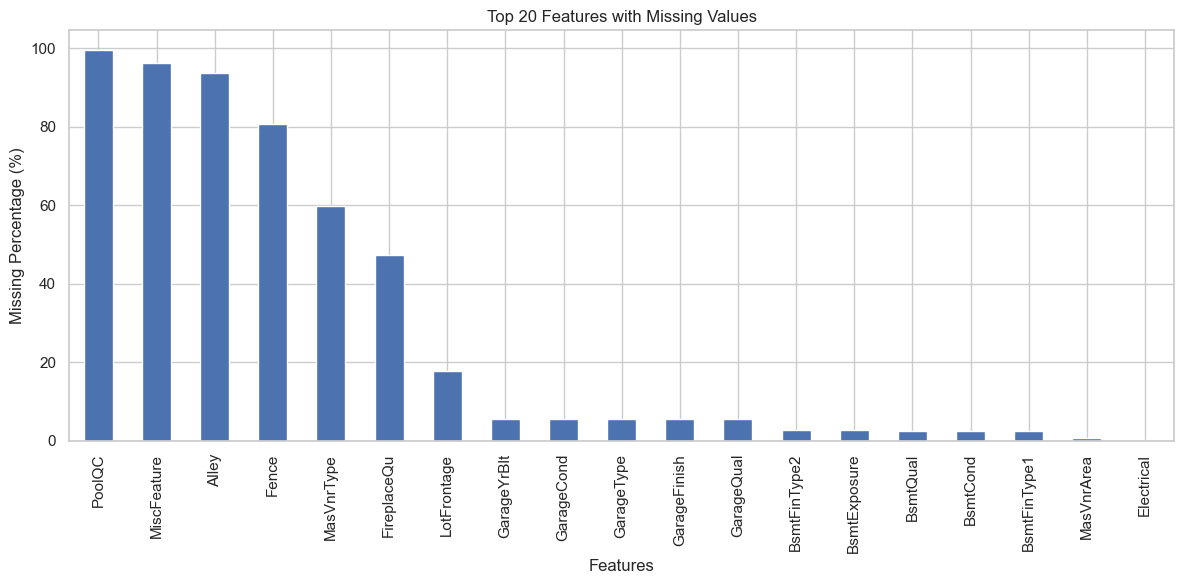

In [10]:
# ============================================================
# 11. VISUALIZE MISSING VALUES
# ============================================================

if len(missing_percentage) > 0:

    plt.figure(figsize=(12, 6))

    missing_percentage.head(20).plot(
        kind="bar"
    )

    plt.title(
        "Top 20 Features with Missing Values"
    )

    plt.xlabel("Features")
    plt.ylabel("Missing Percentage (%)")

    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

In [11]:
# ============================================================
# 12. DUPLICATE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

duplicates = train.duplicated().sum()

print("Number of duplicate rows:",
      duplicates)


DUPLICATE ANALYSIS
Number of duplicate rows: 0


In [12]:
# ============================================================
# 13. CATEGORICAL VARIABLE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("CATEGORICAL VARIABLES")
print("=" * 60)

for column in categorical_columns:

    print("\n--------------------------------")
    print("Column:", column)
    print("--------------------------------")

    print(
        train[column]
        .value_counts()
        .head(10)
    )



CATEGORICAL VARIABLES

--------------------------------
Column: MSZoning
--------------------------------
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

--------------------------------
Column: Street
--------------------------------
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

--------------------------------
Column: Alley
--------------------------------
Alley
Grvl    50
Pave    41
Name: count, dtype: int64

--------------------------------
Column: LotShape
--------------------------------
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

--------------------------------
Column: LandContour
--------------------------------
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

--------------------------------
Column: Utilities
--------------------------------
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

--------------

In [13]:
# ============================================================
# 14. TARGET VARIABLE
# ============================================================

print("\n" + "=" * 60)
print("TARGET VARIABLE")
print("=" * 60)

target = "SalePrice"

print("Target variable:", target)

print("\nTarget statistics:")
print(train[target].describe())

print("\nMean SalePrice:",
      train[target].mean())

print("Median SalePrice:",
      train[target].median())

print("Minimum SalePrice:",
      train[target].min())

print("Maximum SalePrice:",
      train[target].max())




TARGET VARIABLE
Target variable: SalePrice

Target statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Mean SalePrice: 180921.19589041095
Median SalePrice: 163000.0
Minimum SalePrice: 34900
Maximum SalePrice: 755000


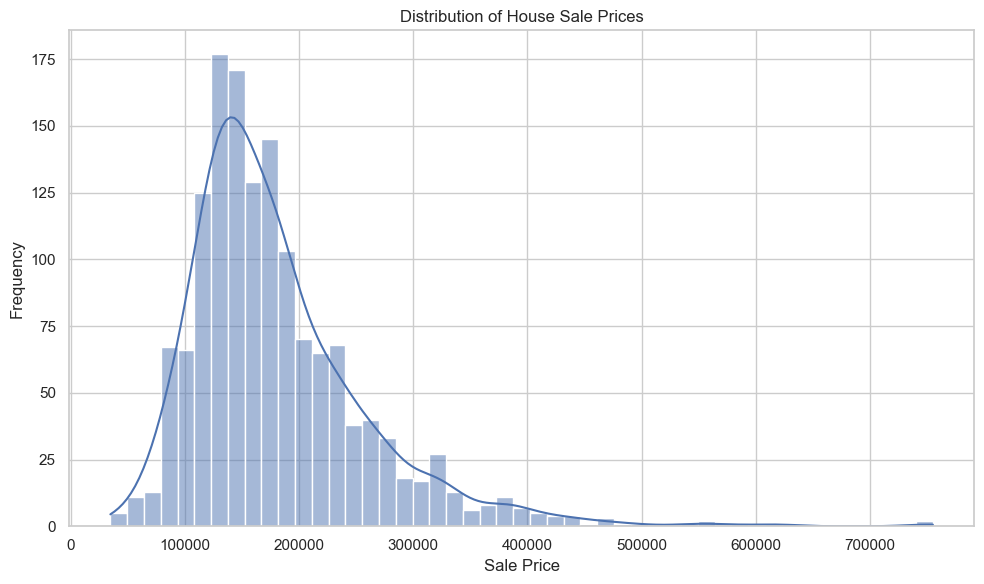

In [14]:
# ============================================================
# 15. SALEPRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    train["SalePrice"],
    kde=True
)

plt.title(
    "Distribution of House Sale Prices"
)

plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

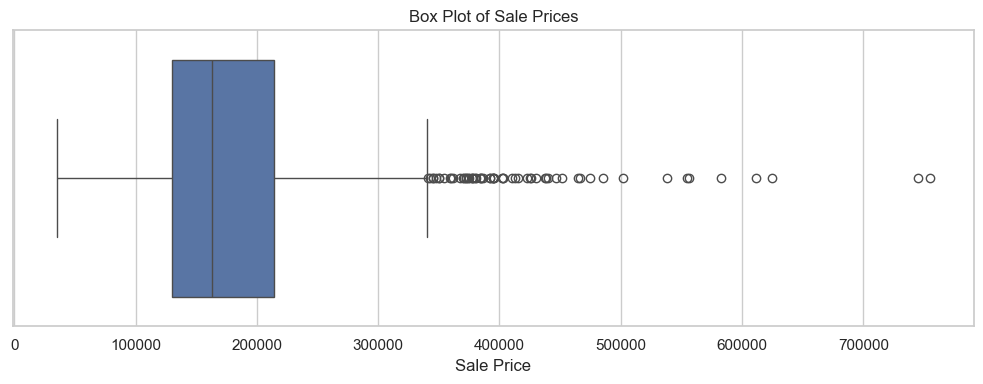

In [15]:
# ============================================================
# 16. SALEPRICE BOXPLOT
# ============================================================

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=train["SalePrice"]
)

plt.title(
    "Box Plot of Sale Prices"
)

plt.xlabel("Sale Price")

plt.tight_layout()
plt.show()

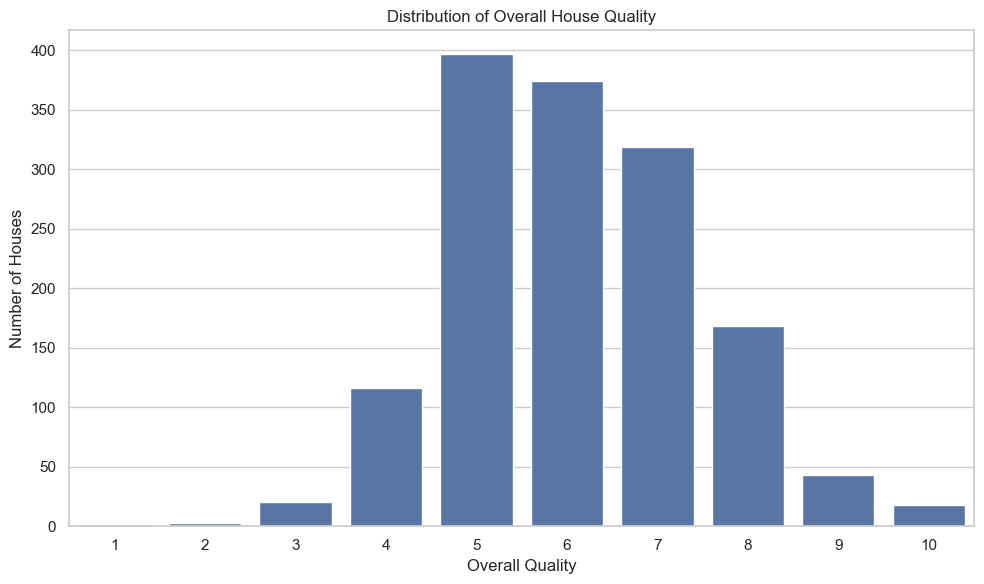

In [16]:
# ============================================================
# 17. OVERALL QUALITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=train,
    x="OverallQual"
)

plt.title(
    "Distribution of Overall House Quality"
)

plt.xlabel("Overall Quality")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()

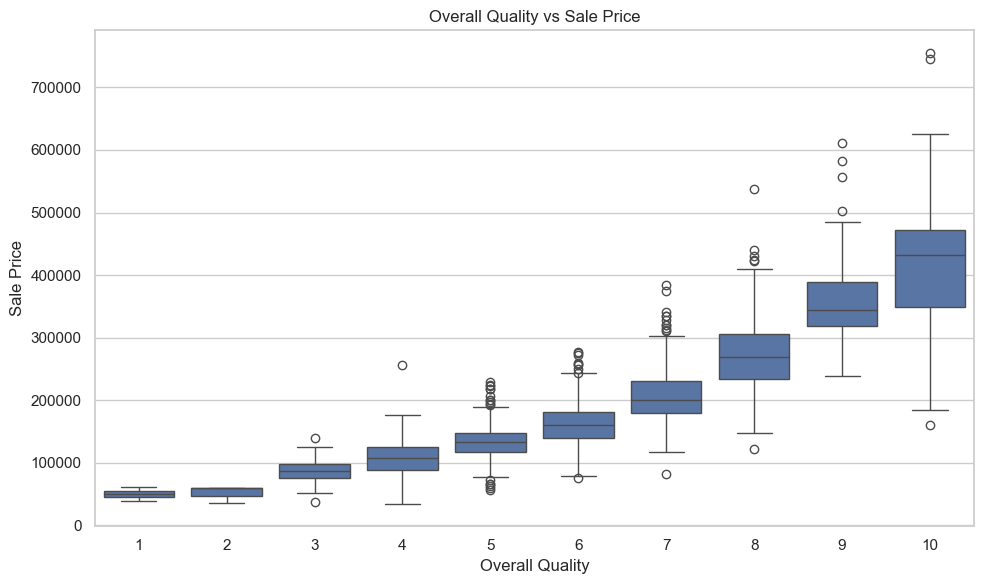

In [17]:
# ============================================================
# 18. OVERALL QUALITY VS SALEPRICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train,
    x="OverallQual",
    y="SalePrice"
)

plt.title(
    "Overall Quality vs Sale Price"
)

plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

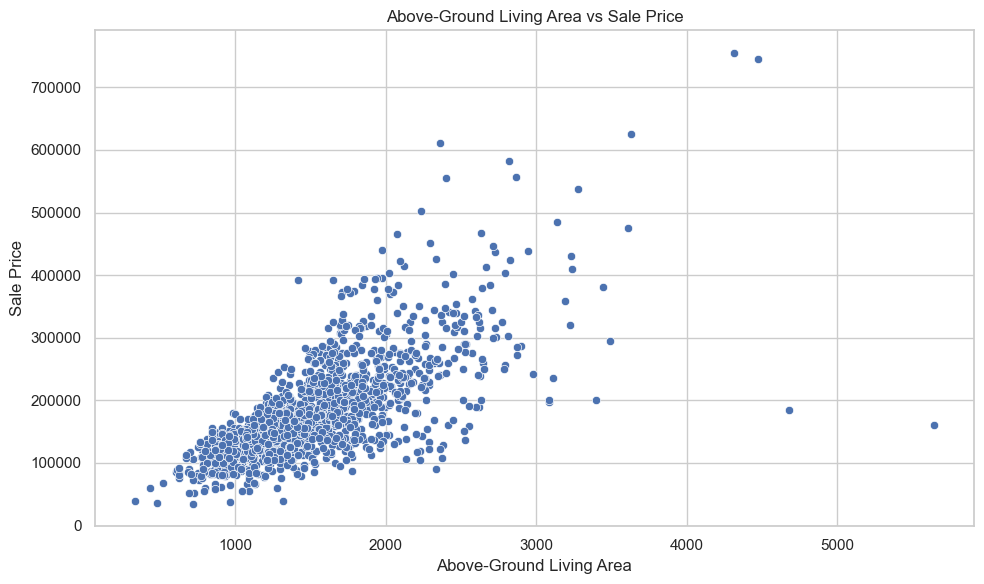

In [18]:
# ============================================================
# 19. LIVING AREA VS SALEPRICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice"
)

plt.title(
    "Above-Ground Living Area vs Sale Price"
)

plt.xlabel(
    "Above-Ground Living Area"
)

plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

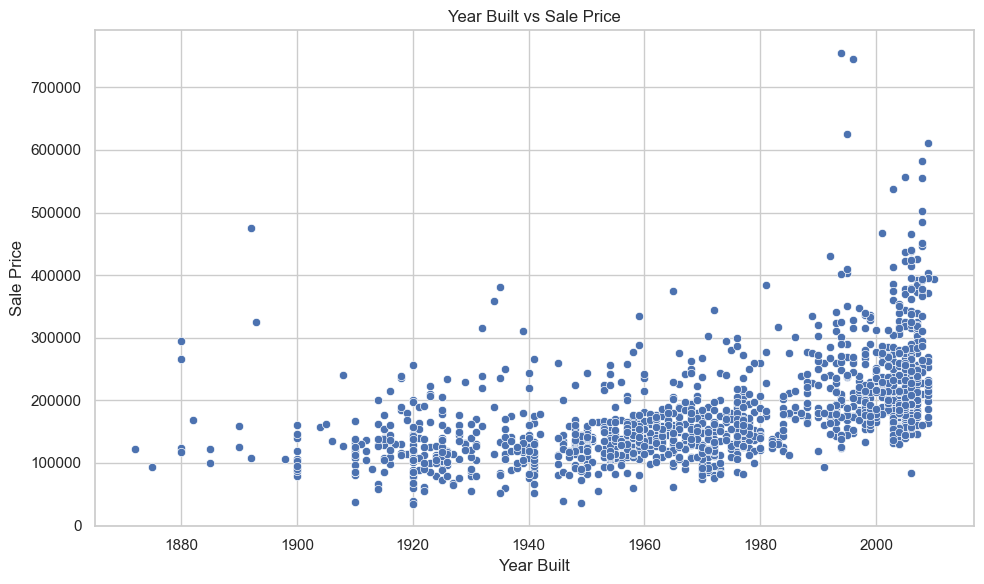

In [19]:
# ============================================================
# 20. YEAR BUILT VS SALEPRICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train,
    x="YearBuilt",
    y="SalePrice"
)

plt.title(
    "Year Built vs Sale Price"
)

plt.xlabel("Year Built")
plt.ylabel("Sale Price")

plt.tight_layout()


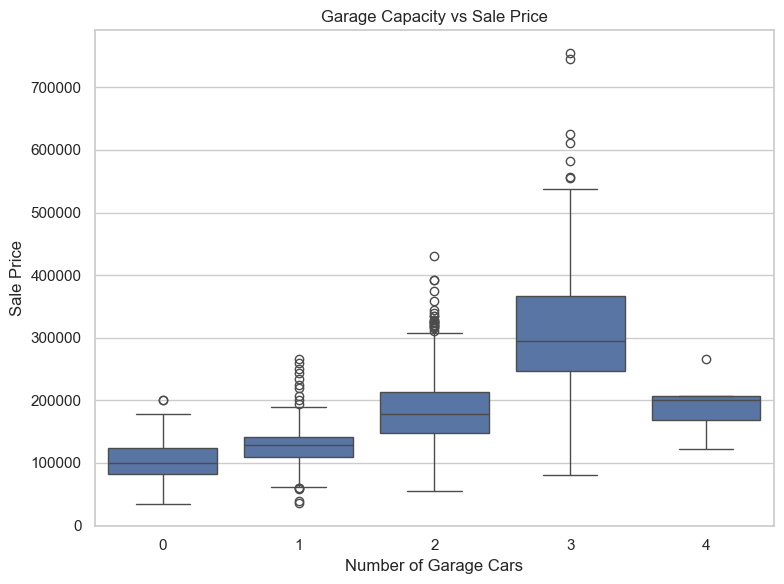

In [20]:
# ============================================================
# 21. GARAGE CAPACITY VS SALEPRICE
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=train,
    x="GarageCars",
    y="SalePrice"
)

plt.title(
    "Garage Capacity vs Sale Price"
)

plt.xlabel(
    "Number of Garage Cars"
)

plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()


AVERAGE PRICE BY NEIGHBORHOOD
Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


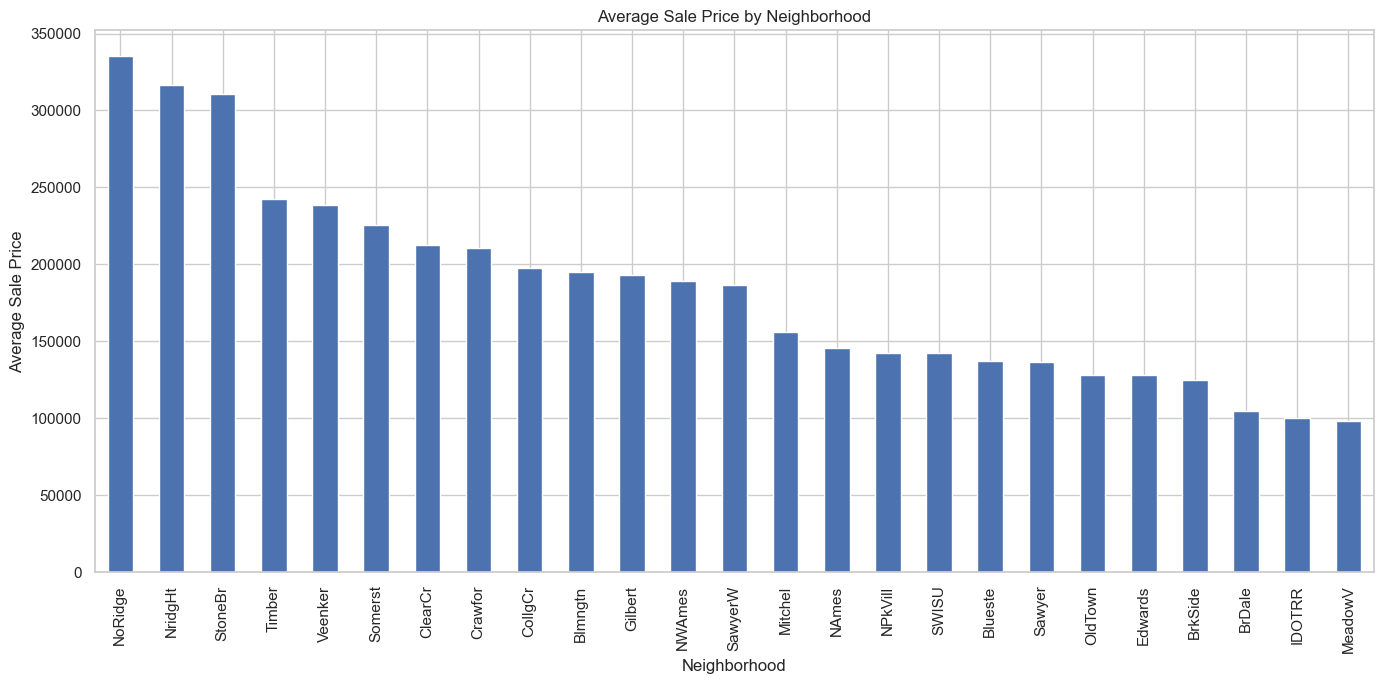

In [21]:
# ============================================================
# 22. NEIGHBORHOOD ANALYSIS
# ============================================================
neighborhood_prices = (
    train.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(
        ascending=False
    )
)

print("\n" + "=" * 60)
print("AVERAGE PRICE BY NEIGHBORHOOD")
print("=" * 60)

print(neighborhood_prices)


plt.figure(figsize=(14, 7))

neighborhood_prices.plot(
    kind="bar"
)

plt.title(
    "Average Sale Price by Neighborhood"
)

plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

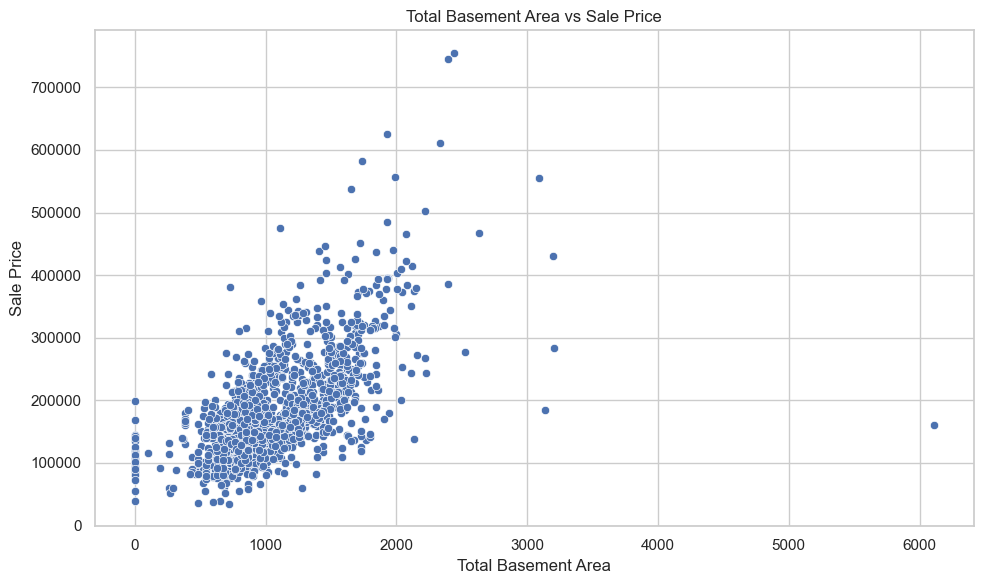

In [22]:
# ============================================================
# 23. BASEMENT AREA VS SALEPRICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train,
    x="TotalBsmtSF",
    y="SalePrice"
)

plt.title(
    "Total Basement Area vs Sale Price"
)

plt.xlabel(
    "Total Basement Area"
)

plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()


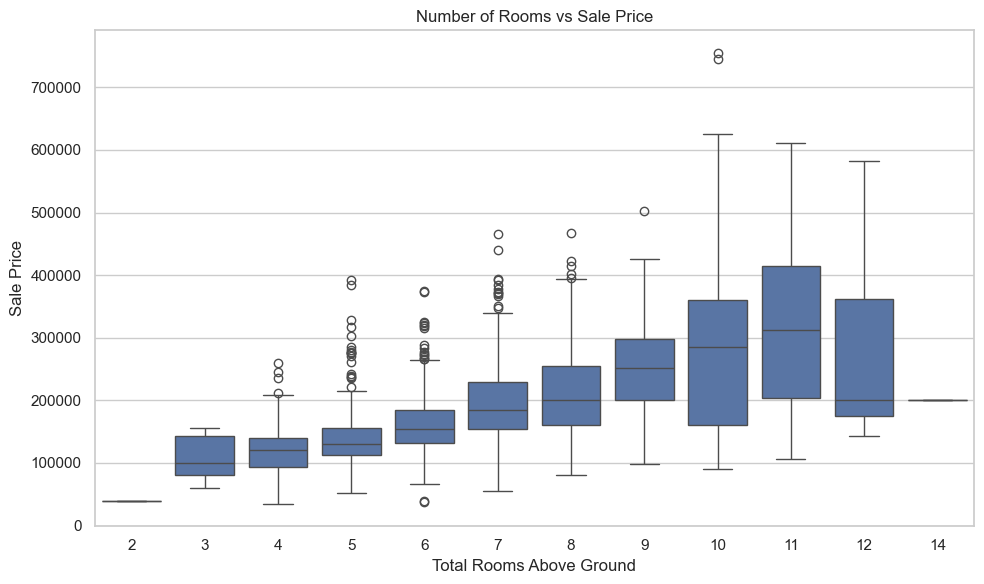

In [23]:

# ============================================================
# 24. ROOMS VS SALEPRICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train,
    x="TotRmsAbvGrd",
    y="SalePrice"
)

plt.title(
    "Number of Rooms vs Sale Price"
)

plt.xlabel(
    "Total Rooms Above Ground"
)

plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 25. CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("CORRELATION WITH SALEPRICE")
print("=" * 60)

numeric_data = train.select_dtypes(
    include=np.number
)

correlation = (
    numeric_data.corr()["SalePrice"]
    .sort_values(
        ascending=False
    )
)

print(correlation)


CORRELATION WITH SALEPRICE
SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbv


Top features correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


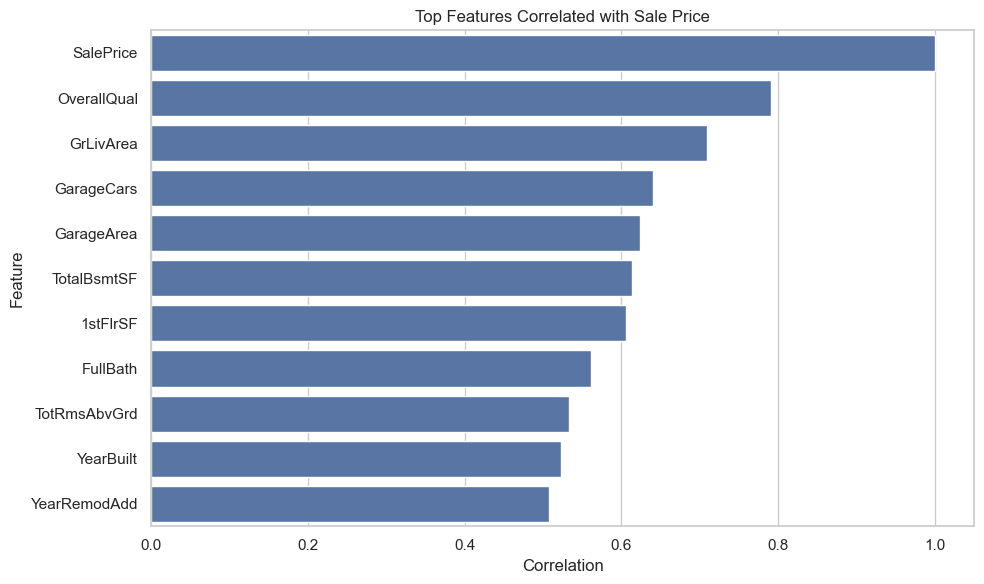

In [25]:
# ============================================================
# 26. TOP CORRELATED FEATURES
# ============================================================

top_features = correlation.head(11)

print("\nTop features correlated with SalePrice:")

print(top_features)


plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title(
    "Top Features Correlated with Sale Price"
)

plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

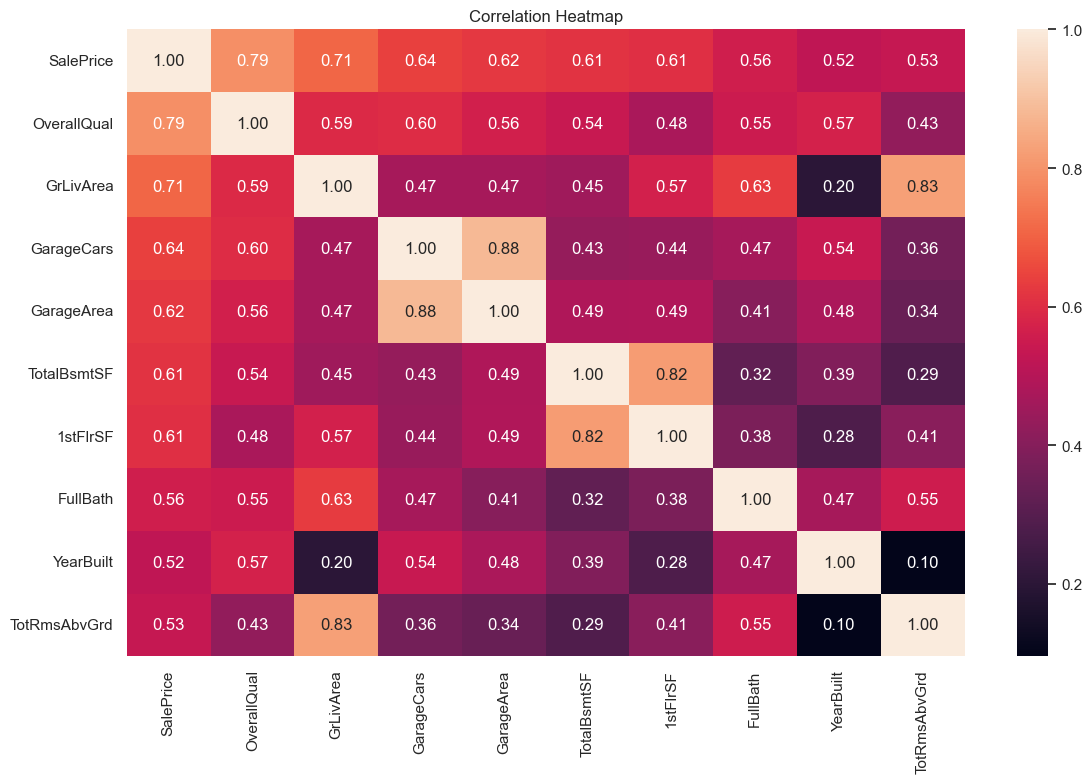

In [26]:
# ============================================================
# 27. CORRELATION HEATMAP
# ============================================================
important_features = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "YearBuilt",
    "TotRmsAbvGrd"
]

correlation_matrix = train[
    important_features
].corr()


plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap"
)

plt.tight_layout()
plt.show()

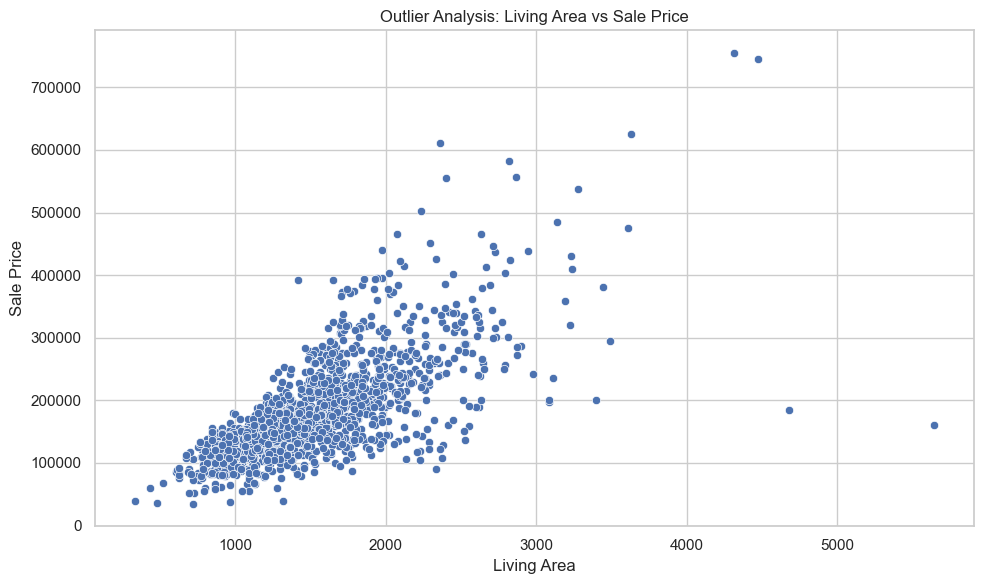

In [27]:
# ============================================================
# 28. OUTLIER ANALYSIS
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice"
)

plt.title(
    "Outlier Analysis: Living Area vs Sale Price"
)

plt.xlabel("Living Area")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# 29. DATA CLEANING
# ============================================================

print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

clean_df = train.copy()


DATA CLEANING


In [29]:
# ------------------------------------------------------------
# Categorical columns where NaN means feature is absent
# ------------------------------------------------------------

none_columns = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

for column in none_columns:

    if column in clean_df.columns:

        clean_df[column] = (
            clean_df[column]
            .fillna("None")
        )




# ------------------------------------------------------------
# Numerical columns where NaN means feature is absent
# ------------------------------------------------------------

zero_columns = [
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]

for column in zero_columns:

    if column in clean_df.columns:

        clean_df[column] = (
            clean_df[column]
            .fillna(0)
        )



# ------------------------------------------------------------
# LotFrontage — use median
# ------------------------------------------------------------

if "LotFrontage" in clean_df.columns:

    clean_df["LotFrontage"] = (
        clean_df["LotFrontage"]
        .fillna(
            clean_df["LotFrontage"].median()
        )
    )

# ------------------------------------------------------------
# Categorical columns — use mode
# ------------------------------------------------------------

mode_columns = [
    "Electrical",
    "MSZoning",
    "Utilities",
    "KitchenQual",
    "Exterior1st",
    "Exterior2nd",
    "SaleType"
]

for column in mode_columns:

    if column in clean_df.columns:

        clean_df[column] = (
            clean_df[column]
            .fillna(
                clean_df[column].mode()[0]
            )
        )


# ------------------------------------------------------------
# Functional — missing means typical
# ------------------------------------------------------------

if "Functional" in clean_df.columns:

    clean_df["Functional"] = (
        clean_df["Functional"]
        .fillna("Typ")
    )


print("Data cleaning completed!")

Data cleaning completed!


In [30]:
# ============================================================
# 30. VERIFY CLEANED DATA
# ============================================================

print("\n" + "=" * 60)
print("VERIFY CLEANED DATA")
print("=" * 60)

remaining_missing = (
    clean_df.isnull().sum()
)

remaining_missing = remaining_missing[
    remaining_missing > 0
].sort_values(
    ascending=False
)

if len(remaining_missing) == 0:

    print("No missing values remain!")

else:

    print(
        "Remaining missing values:"
    )

    print(remaining_missing)


print(
    "\nTotal missing values:",
    clean_df.isnull().sum().sum()
)

print(
    "Total duplicate rows:",
    clean_df.duplicated().sum()
)



VERIFY CLEANED DATA
No missing values remain!

Total missing values: 0
Total duplicate rows: 0


In [31]:

# ============================================================
# 31. SAVE CLEANED DATASET
# ============================================================

output_file = "cleaned_house_prices.csv"

clean_df.to_csv(
    output_file,
    index=False
)

print("\nCleaned dataset saved as:")
print(output_file)


Cleaned dataset saved as:
cleaned_house_prices.csv


In [32]:
# ============================================================
# 32. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATASET INFORMATION")
print("=" * 60)

print("Original shape:",
      train.shape)

print("Cleaned shape:",
      clean_df.shape)

print(
    "Missing values:",
    clean_df.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    clean_df.duplicated().sum()
)


FINAL DATASET INFORMATION
Original shape: (1460, 81)
Cleaned shape: (1460, 81)
Missing values: 0
Duplicate rows: 0


In [33]:
# ============================================================
# 33. FINAL KEY INSIGHTS
# ============================================================

print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

print("""
1. SalePrice is right-skewed, meaning a relatively
   small number of expensive houses create a long
   upper tail.

2. OverallQual has a strong positive relationship
   with SalePrice.

3. Larger above-ground living areas generally have
   higher SalePrices.

4. House prices vary significantly between
   neighborhoods.

5. Garage capacity is generally associated with
   higher house prices.

6. Newer houses tend to have higher SalePrices,
   although the relationship is not perfect.

7. Basement area is positively associated with
   house prices.

8. Several numerical features have strong
   correlations with SalePrice.

9. Some unusual observations can be seen in the
   Living Area vs SalePrice relationship and should
   be investigated as potential outliers.

10. Missing values were handled according to the
    meaning of the corresponding features.
""")


KEY INSIGHTS

1. SalePrice is right-skewed, meaning a relatively
   small number of expensive houses create a long
   upper tail.

2. OverallQual has a strong positive relationship
   with SalePrice.

3. Larger above-ground living areas generally have
   higher SalePrices.

4. House prices vary significantly between
   neighborhoods.

5. Garage capacity is generally associated with
   higher house prices.

6. Newer houses tend to have higher SalePrices,
   although the relationship is not perfect.

7. Basement area is positively associated with
   house prices.

8. Several numerical features have strong
   correlations with SalePrice.

9. Some unusual observations can be seen in the
   Living Area vs SalePrice relationship and should
   be investigated as potential outliers.

10. Missing values were handled according to the
    meaning of the corresponding features.



In [34]:
# ============================================================
# 34. PROJECT COMPLETED
# ============================================================

print("\n" + "=" * 60)
print("HOUSE PRICES EDA PROJECT COMPLETED!")
print("=" * 60)

print("""
Files created:
    cleaned_house_prices.csv

Main analyses completed:
    ✓ Dataset exploration
    ✓ Missing value analysis
    ✓ Duplicate analysis
    ✓ Categorical analysis
    ✓ SalePrice analysis
    ✓ Univariate analysis
    ✓ Bivariate analysis
    ✓ Correlation analysis
    ✓ Heatmap
    ✓ Outlier analysis
    ✓ Data cleaning
    ✓ Cleaned dataset export
""")


HOUSE PRICES EDA PROJECT COMPLETED!

Files created:
    cleaned_house_prices.csv

Main analyses completed:
    ✓ Dataset exploration
    ✓ Missing value analysis
    ✓ Duplicate analysis
    ✓ Categorical analysis
    ✓ SalePrice analysis
    ✓ Univariate analysis
    ✓ Bivariate analysis
    ✓ Correlation analysis
    ✓ Heatmap
    ✓ Outlier analysis
    ✓ Data cleaning
    ✓ Cleaned dataset export

